In [1]:
import math
from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseOracleGate, grover_operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime.options import SamplerOptions
from qiskit.visualization import plot_distribution

In [2]:
# =====================================================================
# 1. DEFINE MULTI-STATE BINARY TO ORACLE CONVERTER
# =====================================================================
def binary_states_to_oracle(binary_states: list[str]) -> PhaseOracleGate:
    """
    Converts a list of target binary strings into a single PhaseOracleGate 
    that marks all specified states. Handles little-endian ordering consistently.
    """
    if not binary_states:
        raise ValueError("The list of binary states cannot be empty.")
        
    num_qubits = len(binary_states[0])
    var_names = [f"v{i}" for i in range(num_qubits)]
    state_clauses = []
    
    for state in binary_states:
        if len(state) != num_qubits:
            raise ValueError("All binary strings must be of the same length.")
            
        reversed_bits = list(reversed(state))
        current_clause = []
        for bit, var in zip(reversed_bits, var_names):
            if bit == "1":
                current_clause.append(var)
            elif bit == "0":
                current_clause.append(f"~{var}")
            else:
                raise ValueError("Strings must contain only '0' or '1'.")
                
        state_clauses.append(f"({' & '.join(current_clause)})")
        
    full_expression = " | ".join(state_clauses)
    print(f"Target States: {binary_states}")
    print(f"Generated Multi-State Expression:\n{full_expression}\n")
    
    return PhaseOracleGate(full_expression, var_order=var_names)


# =====================================================================
# 2. CONFIGURATION & CIRCUITS BUILD
# =====================================================================
# Choose your target states (supports multiple states of equal length)
marked_states = ["101101"]  # or e.g., ["101101", "001100"]

# Build the Oracle Gate
oracle_gate = binary_states_to_oracle(marked_states)
num_qubits = oracle_gate.num_qubits

# Build the complete Grover Operator (Oracle + Diffusion)
grover_op = grover_operator(oracle_gate)

# Compute optimal number of Grover iterations: floor(pi/4 * sqrt(N / M))
N = 2**num_qubits
M = len(marked_states)
iterations = math.floor((math.pi / 4) * math.sqrt(N / M))
print(f"Number of qubits: {num_qubits}")
print(f"Optimal Grover iterations: {iterations}")

# Construct the full abstract Grover Circuit
grover_circuit = QuantumCircuit(num_qubits)
grover_circuit.h(range(num_qubits)) # Initial state initialization (equal superposition)

# Append the Grover step the optimal number of times
for _ in range(iterations):
    grover_circuit.append(grover_op, range(num_qubits))

grover_circuit.measure_all()


# =====================================================================
# 3. SERVICE INITIALIZATION & HARDWARE COMPILATION (ISA)
# =====================================================================
# Connect to IBM Quantum Runtime Service
service = QiskitRuntimeService()

# Automatically discover the least busy operational physical quantum computer
backend = service.least_busy(operational=True, simulator=False)
print(f"\nSelected lowest-queue hardware backend: {backend.name}")

# Generate a high-performance preset pass manager for the target hardware
pm = generate_preset_pass_manager(
    backend=backend, 
    optimization_level=3, 
    layout_method="sabre", 
    routing_method="sabre"
)

# Transpile the abstract Grover circuit into hardware-native layout & instructions
circuit_isa = pm.run(grover_circuit)


# =====================================================================
# 4. SAMPLER CONFIGURATION (D dynamical Decoupling & Error Mitigation)
# =====================================================================
# Instantiate an independent options structure (V2 requirement)
options = SamplerOptions()
options.default_shots = 10_000

# Set up Dynamical Decoupling (DD) to suppress idle spectator dephasing
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"
options.dynamical_decoupling.extra_slack_distribution = "middle"

# Set up Pauli/Error Twirling to scramble systematic coherent noises
options.twirling.enable_gates = True
options.twirling.enable_measure = True

Target States: ['101101']
Generated Multi-State Expression:
(v0 & ~v1 & v2 & v3 & ~v4 & v5)

Number of qubits: 6
Optimal Grover iterations: 6



Selected lowest-queue hardware backend: ibm_kingston


In [3]:
circuit_isa.depth()

5454

In [16]:
# =====================================================================
# 5. EXECUTION
# =====================================================================
# Initialize the target primitive context with the verified parameters
sampler = Sampler(mode=backend, options=options)

print("Submitting the ISA-compliant Grover job to IBM Quantum cloud...")
job = sampler.run([circuit_isa])
print(f"Job successfully created! ID: {job.job_id()}")

Submitting the ISA-compliant Grover job to IBM Quantum cloud...
Job successfully created! ID: d96a3fgtcv6s73djguqg


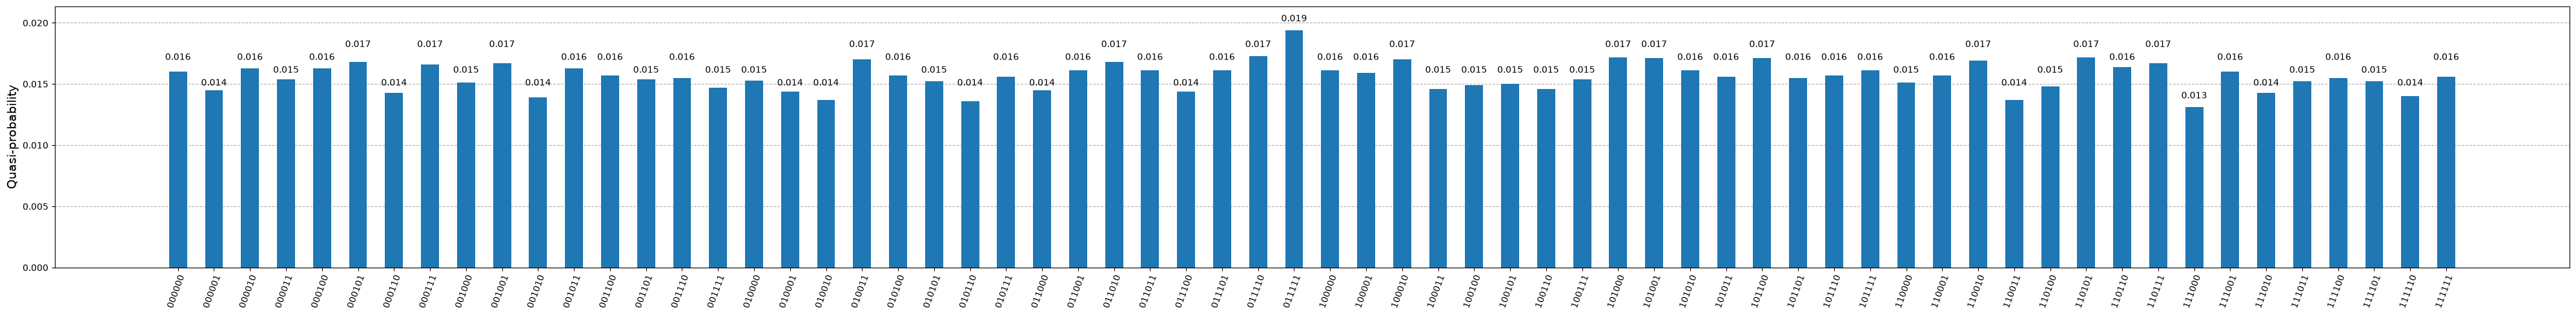

In [3]:
# To extract results later once the status changes to Completed:
result = service.job("d96a3fgtcv6s73djguqg").result()
pub_result = result[0]
counts = pub_result.data.meas.get_counts()
plot_distribution(counts, figsize=(40, 5))